<a href="https://colab.research.google.com/github/jerry124/Aprendizaje-Automatico/blob/main/Practica_Regresion_Precio_Autos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Predicción del precio de automóviles usando modelos de regresión

**Autor:** Gerardo Valdez Martínez  
**Tema:** Regresión en Machine Learning  
**Base de datos:** `CarPrice_Assignment.csv`

En esta práctica se desarrolla un proyecto de Machine Learning para predecir el precio de automóviles a partir de sus características técnicas y comerciales.

La variable que se desea predecir es `price`, por lo tanto este problema corresponde a un caso de **regresión supervisada**, ya que la salida es un valor numérico continuo.

## 1. Objetivo de la práctica

El objetivo principal es construir y evaluar modelos de regresión capaces de estimar el precio de un automóvil considerando variables como el tamaño del motor, caballos de fuerza, peso, consumo de combustible, tipo de carrocería, tipo de combustible, entre otras.

Además, se busca comparar distintos modelos para identificar cuál ofrece mejor desempeño.

## 2. Importación de librerías

En esta sección se importan las librerías necesarias para trabajar con datos, generar gráficas, preparar las variables y entrenar modelos de Machine Learning.

In [17]:
# Librerías para manejo de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas para dividir datos y evaluar modelos
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Herramientas para preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos de regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Para evitar mostrar advertencias innecesarias
import warnings
warnings.filterwarnings("ignore")

## 3. Carga de la base de datos

La base de datos contiene información de distintos automóviles. Cada fila representa un vehículo y cada columna describe una característica.

Para trabajar en Google Colab, primero se debe subir el archivo `CarPrice_Assignment.csv`.

In [18]:
# Cargar el archivo CSV
# En Google Colab, primero sube el archivo CarPrice_Assignment.csv al panel de archivos.

ruta = "CarPrice_Assignment.csv"

try:
    df = pd.read_csv(ruta)
except FileNotFoundError:
    # Esta ruta funciona si el archivo está en /mnt/data, como cuando se ejecuta localmente en este entorno.
    df = pd.read_csv("/mnt/data/CarPrice_Assignment.csv")

# Mostrar las primeras filas
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## 4. Exploración inicial de los datos

Antes de entrenar cualquier modelo, es importante conocer la estructura de la base de datos.

Aquí reviso cuántos registros tiene, cuántas columnas existen, qué tipo de datos contiene y si hay valores faltantes.

In [19]:
print("Número de filas y columnas:")
print(df.shape)

print("\nColumnas de la base de datos:")
print(df.columns.tolist())

Número de filas y columnas:
(205, 26)

Columnas de la base de datos:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


In [20]:
# Información general de las variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [21]:
# Revisión de valores nulos
valores_nulos = df.isnull().sum()
valores_nulos[valores_nulos > 0]

,0


In [22]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
car_ID,205.0,103.000000,59.322565,1.00,52.00,103.00,154.00,205.00
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
enginesize,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17




La base contiene variables numéricas y categóricas. Esto significa que antes de entrenar los modelos se deben preparar los datos.

Las variables numéricas pueden usarse directamente, pero las variables categóricas como `fueltype`, `carbody`, `drivewheel` o `enginetype` deben transformarse a valores numéricos mediante codificación One-Hot Encoding.

La variable objetivo es `price`, por lo que se trata de un problema de regresión.

## 5. Limpieza y preparación inicial

La columna `car_ID` solo identifica cada automóvil, pero no aporta información útil para predecir el precio. Por eso se elimina.

La columna `CarName` contiene el nombre completo del automóvil. A partir de ella se extrae la marca, porque la marca sí puede influir en el precio.

In [23]:
# Crear una copia para no modificar directamente el DataFrame original
datos = df.copy()

# Extraer la marca del automóvil a partir de la primera palabra de CarName
datos["brand"] = datos["CarName"].str.split().str[0].str.lower()

# Algunas marcas aparecen escritas con pequeñas variaciones. Las corregimos para unificar.
datos["brand"] = datos["brand"].replace({
    "maxda": "mazda",
    "porcshce": "porsche",
    "toyouta": "toyota",
    "vokswagen": "volkswagen",
    "vw": "volkswagen"
})

# Eliminar columnas que no se usarán directamente
# car_ID es identificador y CarName ya fue resumida en brand
datos = datos.drop(columns=["car_ID", "CarName"])

# Verificar el resultado
datos.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


## 6. Análisis visual de la variable objetivo

Primero se analiza cómo se distribuyen los precios de los automóviles. Esto ayuda a observar si existen autos muy caros o si la mayoría se concentra en cierto rango.

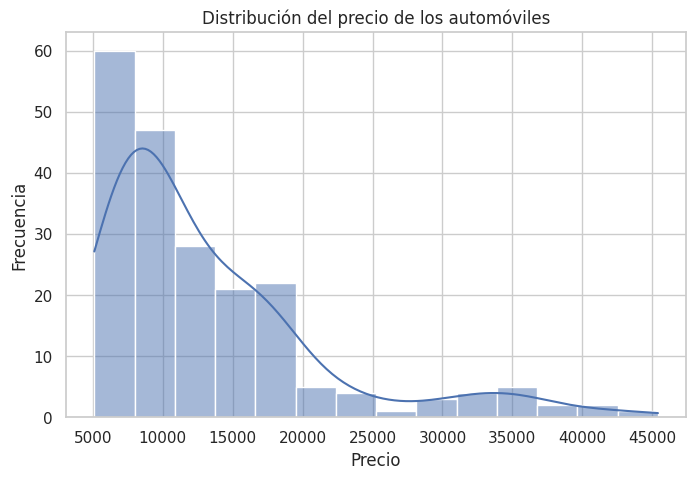

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(datos["price"], kde=True)
plt.title("Distribución del precio de los automóviles")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

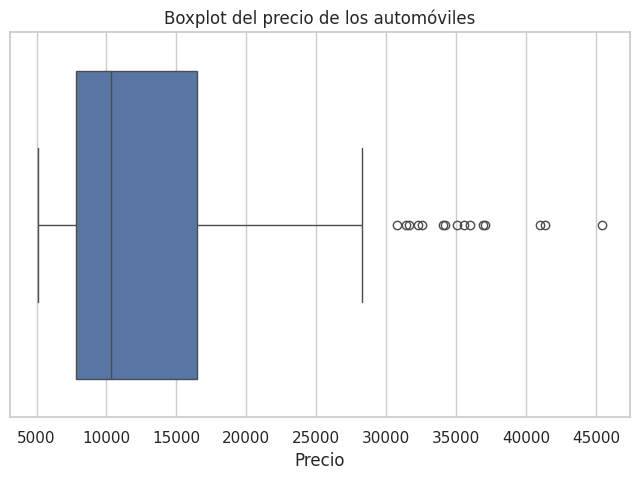

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x=datos["price"])
plt.title("Boxplot del precio de los automóviles")
plt.xlabel("Precio")
plt.show()

La mayoría de los automóviles se concentra en precios bajos y medios, mientras que existen algunos vehículos con precios más elevados.

Esto es normal en este tipo de datos, porque no todos los autos pertenecen al mismo segmento. Algunos pueden ser económicos y otros de gama más alta.

## 7. Relación entre variables numéricas y precio

Ahora se revisa la relación entre algunas variables importantes y el precio. Esto permite identificar patrones antes de construir el modelo.

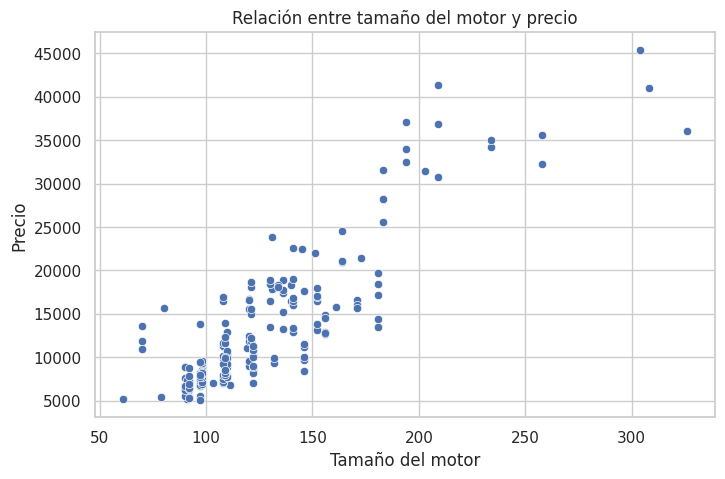

In [26]:
# Relación entre tamaño del motor y precio
plt.figure(figsize=(8,5))
sns.scatterplot(data=datos, x="enginesize", y="price")
plt.title("Relación entre tamaño del motor y precio")
plt.xlabel("Tamaño del motor")
plt.ylabel("Precio")
plt.show()

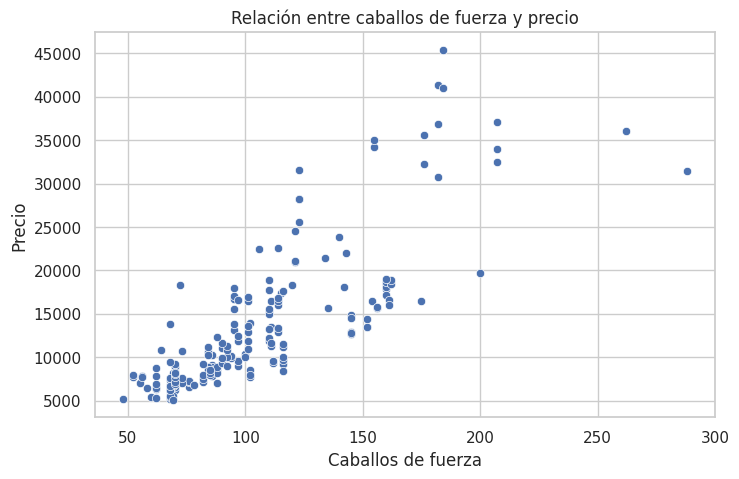

In [27]:
# Relación entre caballos de fuerza y precio
plt.figure(figsize=(8,5))
sns.scatterplot(data=datos, x="horsepower", y="price")
plt.title("Relación entre caballos de fuerza y precio")
plt.xlabel("Caballos de fuerza")
plt.ylabel("Precio")
plt.show()

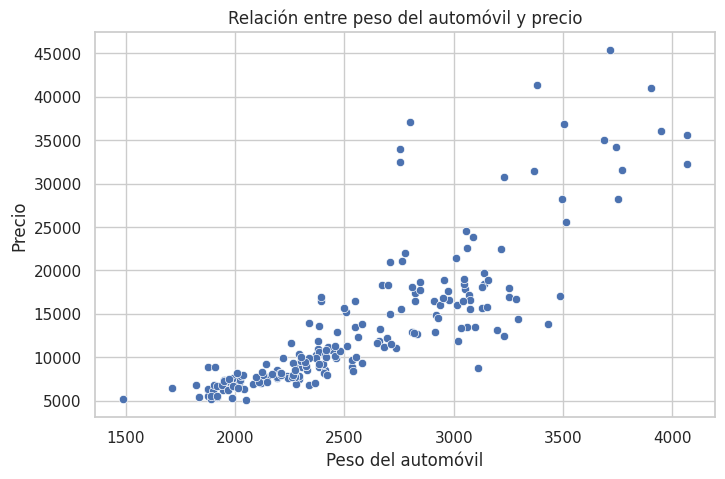

In [28]:
# Relación entre peso del automóvil y precio
plt.figure(figsize=(8,5))
sns.scatterplot(data=datos, x="curbweight", y="price")
plt.title("Relación entre peso del automóvil y precio")
plt.xlabel("Peso del automóvil")
plt.ylabel("Precio")
plt.show()

### Interpretación

Se observa que variables como `enginesize`, `horsepower` y `curbweight` tienen una relación positiva con el precio.

Esto significa que, en general, los automóviles con motores más grandes, mayor potencia y mayor peso tienden a tener precios más altos.

## 8. Matriz de correlación

La matriz de correlación permite observar qué variables numéricas tienen mayor relación con el precio.

Una correlación cercana a 1 indica una relación positiva fuerte, mientras que una correlación cercana a -1 indica una relación negativa fuerte.

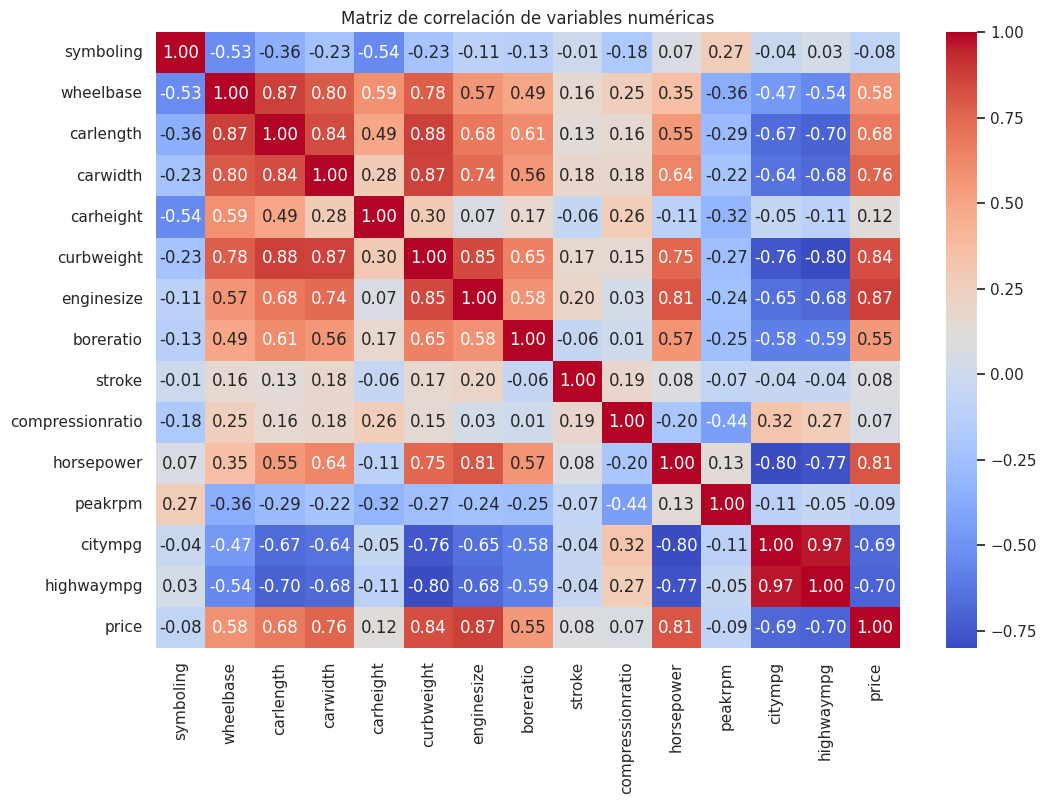

In [29]:
# Seleccionar solo variables numéricas
numericas = datos.select_dtypes(include=["int64", "float64"])

# Calcular correlación
corr = numericas.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación de variables numéricas")
plt.show()

In [30]:
# Correlación de cada variable numérica con price
corr_price = corr["price"].sort_values(ascending=False)
corr_price

,price
price,1.000000
enginesize,0.874145
curbweight,0.835305
horsepower,0.808139
carwidth,0.759325
carlength,0.682920
wheelbase,0.577816
boreratio,0.553173
carheight,0.119336
stroke,0.079443


### Interpretación de correlaciones

Las variables con mayor relación positiva con el precio suelen ser:

- `enginesize`
- `curbweight`
- `horsepower`
- `carwidth`

Mientras que variables como `citympg` y `highwaympg` tienden a tener relación negativa, porque los autos más potentes suelen consumir más combustible y tener menor rendimiento.

## 9. Separación de variables de entrada y salida

En esta parte separo la variable que quiero predecir (`price`) de las variables que utilizaré como entrada para el modelo.

In [31]:
# Variable objetivo
y = datos["price"]

# Variables predictoras
X = datos.drop(columns=["price"])

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (205, 24)
Tamaño de y: (205,)


## 10. Identificación de variables numéricas y categóricas

Como la base tiene variables de distinto tipo, se separan las columnas numéricas y categóricas.

Las numéricas se escalan con `StandardScaler` y las categóricas se transforman con `OneHotEncoder`.

In [33]:
# Variables numéricas
variables_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Variables categóricas
variables_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']

Variables categóricas:
['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']


## 11. División en entrenamiento y prueba

Los datos se dividen en dos partes:

- **Entrenamiento:** para que el modelo aprenda.
- **Prueba:** para evaluar qué tan bien predice con datos que no vio durante el entrenamiento.

Se utiliza una división 80/20.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (164, 24)
Datos de prueba: (41, 24)


## 12. Preprocesamiento con Pipeline

Para evitar errores y mantener el proyecto ordenado, se usa un `ColumnTransformer`.

Este permite aplicar distintos tratamientos según el tipo de variable:

- Variables numéricas → escalado.
- Variables categóricas → codificación One-Hot.

In [35]:
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), variables_categoricas)
    ]
)

## 13. Modelos a evaluar

Se comparan diferentes modelos de regresión:

1. **Regresión Lineal:** modelo base e interpretable.
2. **Ridge:** regresión lineal con regularización L2.
3. **Lasso:** regresión lineal con regularización L1.
4. **Random Forest Regressor:** modelo no lineal basado en árboles.
5. **Gradient Boosting Regressor:** modelo avanzado basado en ensamble secuencial.

La comparación permite saber si un modelo simple es suficiente o si conviene usar un modelo más flexible.

In [36]:
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

## 14. Entrenamiento y evaluación de modelos

Cada modelo se entrena con los datos de entrenamiento y se evalúa con los datos de prueba.

Las métricas utilizadas son:

- **MAE:** error absoluto medio.
- **RMSE:** raíz del error cuadrático medio.
- **R²:** porcentaje de variabilidad explicada por el modelo.

In [37]:
resultados = []
predicciones = {}

for nombre, modelo in modelos.items():
    # Crear pipeline completo: preprocesamiento + modelo
    pipeline = Pipeline(steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", modelo)
    ])

    # Entrenar modelo
    pipeline.fit(X_train, y_train)

    # Predicción
    y_pred = pipeline.predict(X_test)
    predicciones[nombre] = y_pred

    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# Crear tabla de resultados
tabla_resultados = pd.DataFrame(resultados).sort_values(by="R2", ascending=False)
tabla_resultados

,Modelo,MAE,RMSE,R2
3,Random Forest,1246.653837,1812.486551,0.958387
4,Gradient Boosting,1666.639761,2384.294495,0.927989
1,Ridge,1881.101369,2757.536284,0.903679
0,Regresión Lineal,1807.703987,2794.407994,0.901085
2,Lasso,1845.652243,2918.531198,0.892103


### Interpretación de métricas

El mejor modelo será el que tenga:

- Mayor valor de **R²**.
- Menor valor de **MAE**.
- Menor valor de **RMSE**.

En este caso, los modelos basados en árboles pueden funcionar mejor porque capturan relaciones no lineales entre las características del automóvil y su precio.

## 15. Gráfica comparativa de los modelos

Esta gráfica ayuda a observar visualmente cuál modelo obtuvo mejor rendimiento según el valor de R².

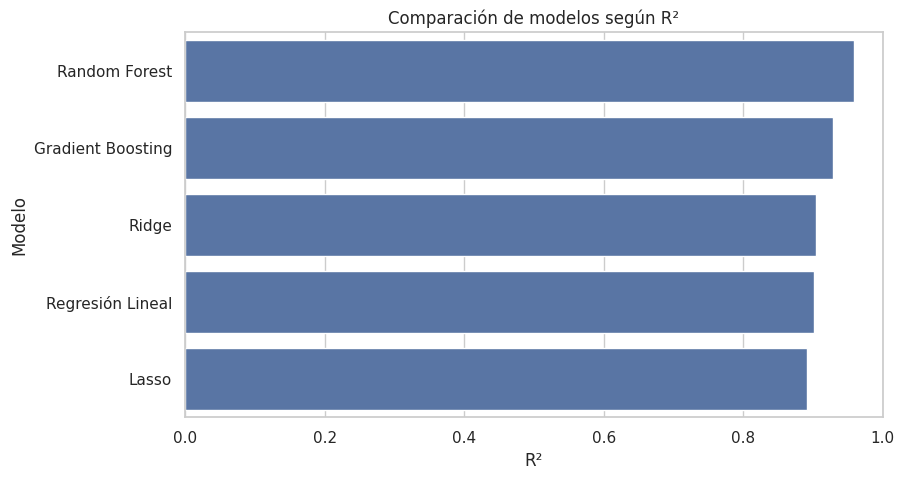

In [38]:
plt.figure(figsize=(9,5))
sns.barplot(data=tabla_resultados, x="R2", y="Modelo")
plt.title("Comparación de modelos según R²")
plt.xlabel("R²")
plt.ylabel("Modelo")
plt.xlim(0, 1)
plt.show()

## 16. Selección del mejor modelo

A partir de la tabla de resultados, se selecciona automáticamente el modelo con mayor R².

In [39]:
mejor_modelo_nombre = tabla_resultados.iloc[0]["Modelo"]
print("El mejor modelo fue:", mejor_modelo_nombre)

mejor_pred = predicciones[mejor_modelo_nombre]

El mejor modelo fue: Random Forest


## 17. Predicción vs valor real

Esta gráfica compara los precios reales contra los precios predichos por el mejor modelo.

Mientras más cerca estén los puntos de la línea diagonal, mejor será la predicción.

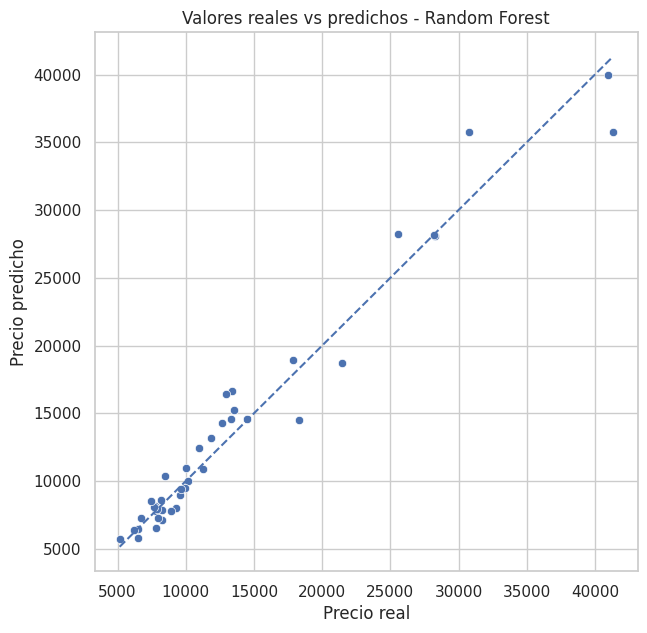

In [40]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=mejor_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--")
plt.title(f"Valores reales vs predichos - {mejor_modelo_nombre}")
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.show()

## 18. Análisis de errores

También es importante revisar los errores del modelo.

El error se calcula como:

`precio real - precio predicho`

Si los errores están cerca de cero, significa que el modelo predice bien.

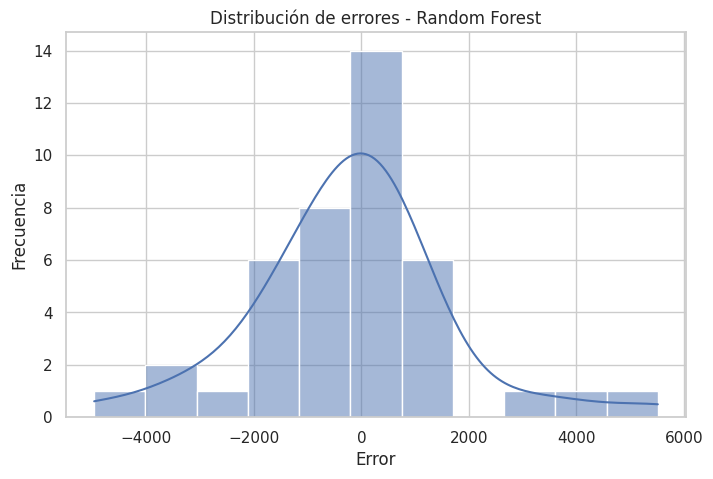

In [41]:
errores = y_test - mejor_pred

plt.figure(figsize=(8,5))
sns.histplot(errores, kde=True)
plt.title(f"Distribución de errores - {mejor_modelo_nombre}")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

## 19. Importancia de variables en Random Forest

Si el mejor modelo es Random Forest, podemos revisar qué variables influyen más en la predicción.

Esta parte es útil para interpretar el modelo de forma más clara.

In [42]:
# Entrenar específicamente Random Forest para obtener importancia de variables
rf_pipeline = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("modelo", RandomForestRegressor(n_estimators=300, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

# Obtener nombres de variables después del preprocesamiento
preprocessor_fitted = rf_pipeline.named_steps["preprocesamiento"]

num_features = variables_numericas
cat_features = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(variables_categoricas).tolist()
feature_names = num_features + cat_features

importancias = rf_pipeline.named_steps["modelo"].feature_importances_

importancia_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

importancia_df.head(15)

,Variable,Importancia
6,enginesize,0.586798
5,curbweight,0.258231
13,highwaympg,0.045798
10,horsepower,0.027551
3,carwidth,0.015285
2,carlength,0.008245
1,wheelbase,0.006827
12,citympg,0.006555
53,brand_bmw,0.006522
11,peakrpm,0.005720


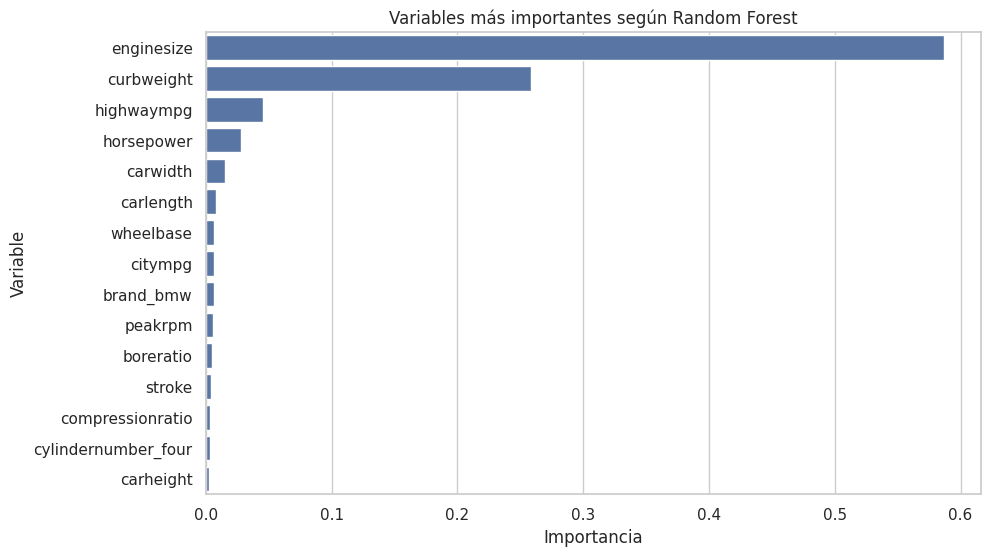

In [43]:
plt.figure(figsize=(10,6))
sns.barplot(data=importancia_df.head(15), x="Importancia", y="Variable")
plt.title("Variables más importantes según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()



Las variables con mayor importancia son las que más ayudan al modelo a explicar el precio del automóvil.

Normalmente, variables como el tamaño del motor, el peso del vehículo, la potencia y las dimensiones del automóvil suelen tener un papel importante en la predicción del precio.

## 20. Ejemplo de predicción individual

Para comprobar el funcionamiento del modelo, se toma un automóvil del conjunto de prueba y se compara su precio real contra el precio estimado por el modelo.

In [44]:
# Tomar un ejemplo del conjunto de prueba
ejemplo = X_test.iloc[[0]]
precio_real = y_test.iloc[0]
precio_predicho = rf_pipeline.predict(ejemplo)[0]

print("Precio real:", round(precio_real, 2))
print("Precio predicho:", round(precio_predicho, 2))
print("Diferencia:", round(precio_real - precio_predicho, 2))

ejemplo

Precio real: 30760.0
Precio predicho: 35733.14
Diferencia: -4973.14


,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,brand
15,0,gas,std,four,sedan,rwd,front,103.5,189.0,66.9,...,209,mpfi,3.62,3.39,8.0,182,5400,16,22,bmw


## 21. Conclusión general

En esta práctica se desarrolló un modelo de Machine Learning para predecir el precio de automóviles utilizando la base `CarPrice_Assignment.csv`.

El problema corresponde a un caso de **regresión supervisada**, porque la variable objetivo `price` es numérica y continua.

Durante el análisis se observó que variables como el tamaño del motor, los caballos de fuerza, el peso del automóvil y algunas características categóricas influyen en el precio.

Se evaluaron distintos modelos, desde regresión lineal hasta modelos de ensamble como Random Forest y Gradient Boosting. Esta comparación permitió observar que los modelos no lineales pueden capturar mejor la relación entre las características del vehículo y su precio.

En conclusión, esta base de datos es adecuada para un proyecto de regresión, y el modelo más recomendable será aquel que obtenga mayor R² y menor error en las métricas MAE y RMSE.

En esta práctica utilicé una base de datos de automóviles para predecir su precio a partir de características técnicas como el tamaño del motor, la potencia, el peso, el consumo de combustible y el tipo de carrocería. Como la variable a predecir es numérica, el problema corresponde a regresión. Primero realicé un análisis exploratorio para conocer los datos, después transformé las variables categóricas y escalé las variables numéricas. Posteriormente comparé varios modelos y evalué su desempeño con MAE, RMSE y R². Finalmente, seleccioné el modelo con mejor rendimiento y analicé qué variables fueron más importantes en la predicción del precio.

